# Lab 11: Grid Localization using Bayes Filter (Real Robot)

### <span style="color:rgb(0,150,0)">It is recommended that you close any heavy-duty applications running on your system while working on this lab.</span>

### <span style="color:rgb(0,150,0)">The notebook only provides skeleton code for you to integrate the Localization class with the Real Robot.</span>

<hr>

In [1]:
GROUND_TRUTH = (1.524, 0.914, 0.0) 


In [2]:
# Cell 1: Importing and setting up the environment

%load_ext autoreload
%autoreload 2

import sys
import asyncio
import pathlib
import os
import numpy as np

import traceback
from notebook_utils import *
from Traj import *
from utils import load_config_params
from localization_extras import Localization

# Make the project's main_python BLE client importable.
_BLE_ROOT = pathlib.Path(os.getcwd()).resolve().parent.parent / "ble_robot_1.4"
if str(_BLE_ROOT) not in sys.path:
    sys.path.insert(0, str(_BLE_ROOT))

from main_python.ble.connection import BLEConnection
from main_python.commands import MapStart, SendMapData, MapStatus

# Setup Logger
LOG = get_logger('demo_notebook.log')
LOG.propagate = False

# Init GUI and Commander
gui = GET_GUI()
cmdr = gui.launcher.commander




2026-04-27 19:55:13,136 | INFO     |: Logger demo_notebook.log initialized.


In [3]:
# Cell 2: Start the plotter

# Start the plotter
START_PLOTTER()


# The RealRobot class
Define the RealRobot class in the code cell below, based on the documentation and your real robot communication protocol. <br>
This class is used by the **Localization** class to communicate with the real robot. <br>
More specifically, the **Localization** class utilizes the **RealRobot's** member function **perform_observation_loop()** to get the 18 sensor readings and store them in its member variable **obs_range_data**, which is then utilized in the update step.

In [4]:
# Cell 3: Define the RealRobot class

class RealRobot():
    """A class to interact with the real robot using the async main_python BLE client."""

    def __init__(self, commander, ble):
        self.world_config = os.path.join(
            str(pathlib.Path(os.getcwd()).parent), "config", "world.yaml"
        )
        self.config_params = load_config_params(self.world_config)
        self.cmdr = commander
        self.ble = ble  # BLEConnection (already entered)

    def get_pose(self):
        raise NotImplementedError("get_pose is not implemented")

    async def perform_observation_loop(self, rot_vel=120):
        """Drive the firmware mapping subsystem through an 18-step 360 sweep
        and return the per-bucket ToF means as an (18, 1) numpy column array
        in meters. Bearings are not used by the localization module, so an
        empty array is returned.
        """
        await self.ble.execute(MapStart(num_steps=18))
        while await self.ble.execute(MapStatus()):
            await asyncio.sleep(0.5)

        buckets = await self.ble.execute(SendMapData())
        buckets.sort(key=lambda b: b.index)
        ranges_m = np.array([b.distance / 1000.0 for b in buckets])
        return ranges_m[np.newaxis].T, np.array([])


In [5]:
# Cell 4: Open the BLE connection

# Open the async BLE connection to the Artemis. The connection stays
# open for the lifetime of the notebook session.
ble = BLEConnection()
await ble.__aenter__()


In [6]:
# Cell 5: Initialize the RealRobot, Mapper, and Localization objects

# Initialize RealRobot with a Commander object to communicate with the plotter process
# and the ArtemisBLEController object to communicate with the real robot
robot = RealRobot(cmdr, ble)

# Initialize mapper
# Requires a VirtualRobot object as a parameter
mapper = Mapper(robot)

# Initialize your BaseLocalization object
# Requires a RealRobot object and a Mapper object as parameters
loc = Localization(robot, mapper)

## Plot Map
cmdr.plot_map()


2026-04-27 19:55:25,309 | INFO     |:  | Number of observations per grid cell: 18
2026-04-27 19:55:25,311 | INFO     |:  | Precaching Views...
2026-04-27 19:55:30,498 | INFO     |:  | Precaching Time: 5.186 secs
2026-04-27 19:55:30,499 | INFO     |: Initializing beliefs with a Uniform Distribution
2026-04-27 19:55:30,500 | INFO     |: Uniform Belief with each cell value: 2.8577960676726108e-05


# Run an update step of the Bayes Filter

In [15]:
# Cell 6: Run the localization update step

# Reset Plots
cmdr.reset_plotter()

# Init Uniform Belief
loc.init_grid_beliefs()

# Get Observation Data by executing a 360 degree rotation motion
await loc.get_observation_data()

# Run Update Step
loc.update_step()
loc.plot_update_step_data(plot_data=True)


2026-04-27 20:03:29,278 | INFO     |: Initializing beliefs with a Uniform Distribution
2026-04-27 20:03:29,281 | INFO     |: Uniform Belief with each cell value: 2.8577960676726108e-05


[BLE] TX MapStart req_id=131 cmd_id=47 (8 bytes)
[BLE] TX MapStatus req_id=132 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=133 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=134 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=135 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=136 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=137 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=138 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=139 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=140 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=141 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=142 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=143 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=144 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=145 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=146 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=147 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=148 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=149 cmd_id=51 (3 bytes)
[BLE] TX MapStatus req_id=150 cmd_id=51 (3 bytes)
[

2026-04-27 20:04:37,861 | INFO     |: Update Step
2026-04-27 20:04:37,878 | INFO     |:      | Update Time: 0.015 secs
2026-04-27 20:04:37,879 | INFO     |: Bel index     : (np.int64(31), np.int64(22), np.int64(18)) with prob = 0.0507715
2026-04-27 20:04:37,880 | INFO     |: Bel_bar prob at index = 2.8577960676726108e-05
2026-04-27 20:04:37,880 | INFO     |: Belief        : (1.524, 0.914, 5.000)


[BLE] TX MapStatus req_id=258 cmd_id=51 (3 bytes)
[BLE] TX SendMapData req_id=259 cmd_id=50 (3 bytes)


In [16]:
# Cell 7: Plot Odom and GT

# Plot Odom and GT
# current_odom, current_gt = robot.get_pose()
# cmdr.plot_gt(current_gt[0], current_gt[1])
# cmdr.plot_odom(current_odom[0], current_odom[1])


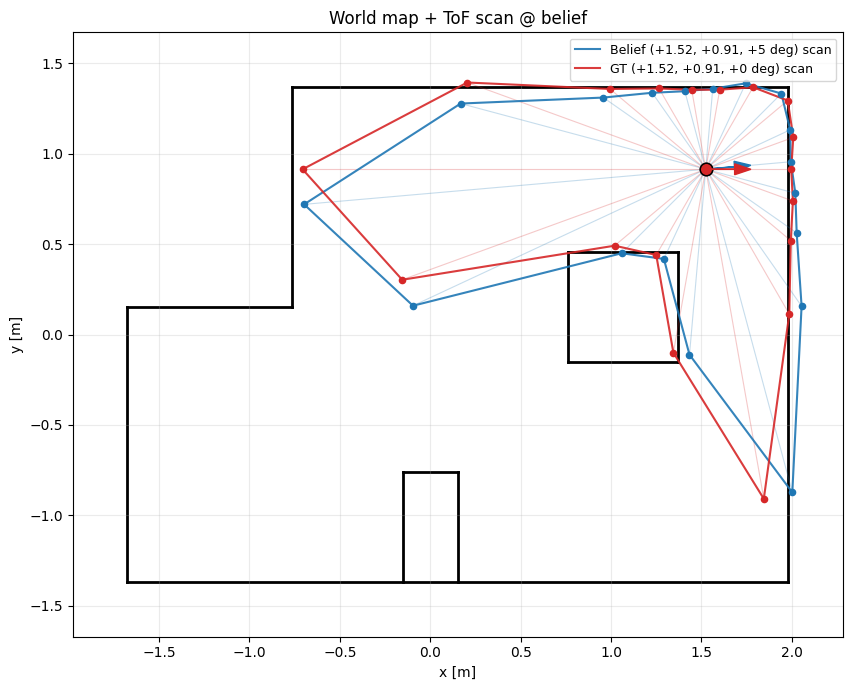

In [17]:
# Cell 8: Overlay the world map with the ToF scan at the believed pose

# Plots the static world (line segments from world.yaml) and the 18 ToF
# endpoints from the most recent observation, placed at the belief pose.
# The localization treats bucket k as the reading at angle (yaw + k * 20)
# degrees in the world frame, so that is exactly what we draw here.
# Pass gt=(x_m, y_m, yaw_deg) to also render the scan from a candidate
# ground-truth pose for visual comparison.

import matplotlib.pyplot as plt
from utils import get_max

def plot_scan_overlay(loc, mapper, gt=None, title=None):
    bel_idx = get_max(loc.bel)[0]
    bx, by, bth = mapper.from_map(*bel_idx)

    ranges = np.asarray(loc.obs_range_data).flatten()
    n = ranges.size
    bucket_deg = np.arange(n) * (360.0 / n)

    fig, ax = plt.subplots(figsize=(9, 7))

    starts, ends = mapper.lines
    for s, e in zip(starts, ends):
        ax.plot([s[0], e[0]], [s[1], e[1]],
                color="black", linewidth=2, zorder=1)

    def draw_pose(x, y, yaw_deg, color, label):
        ang = np.deg2rad(bucket_deg + yaw_deg)
        ex = x + ranges * np.cos(ang)
        ey = y + ranges * np.sin(ang)
        for rx, ry in zip(ex, ey):
            ax.plot([x, rx], [y, ry], color=color,
                    alpha=0.25, linewidth=0.8, zorder=2)
        loop_x = np.append(ex, ex[0]); loop_y = np.append(ey, ey[0])
        ax.plot(loop_x, loop_y, "-", color=color, linewidth=1.5,
                alpha=0.9, zorder=3, label=f"{label} scan")
        ax.scatter(ex, ey, color=color, s=20, zorder=4)
        ax.scatter([x], [y], color=color, marker="o", s=80,
                   edgecolor="black", zorder=5)
        hx = 0.25 * np.cos(np.deg2rad(yaw_deg))
        hy = 0.25 * np.sin(np.deg2rad(yaw_deg))
        ax.arrow(x, y, hx, hy, head_width=0.06, color=color,
                 zorder=5, length_includes_head=True)

    draw_pose(bx, by, bth, "tab:blue",
              f"Belief ({bx:+.2f}, {by:+.2f}, {bth:+.0f} deg)")

    if gt is not None:
        gx, gy, gth = gt
        draw_pose(gx, gy, gth, "tab:red",
                  f"GT ({gx:+.2f}, {gy:+.2f}, {gth:+.0f} deg)")

    ax.set_aspect("equal")
    ax.set_xlim(mapper.MIN_X - 0.3, mapper.MAX_X + 0.3)
    ax.set_ylim(mapper.MIN_Y - 0.3, mapper.MAX_Y + 0.3)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_title(title or "World map + ToF scan @ belief")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

# Pose 1 GT in meters: (-3 ft, -2 ft, 0 deg) -> (-0.914, -0.610, 0)
# Replace gt=(...) with the GT of whichever pose you just measured.
plot_scan_overlay(loc, mapper, gt=GROUND_TRUTH)


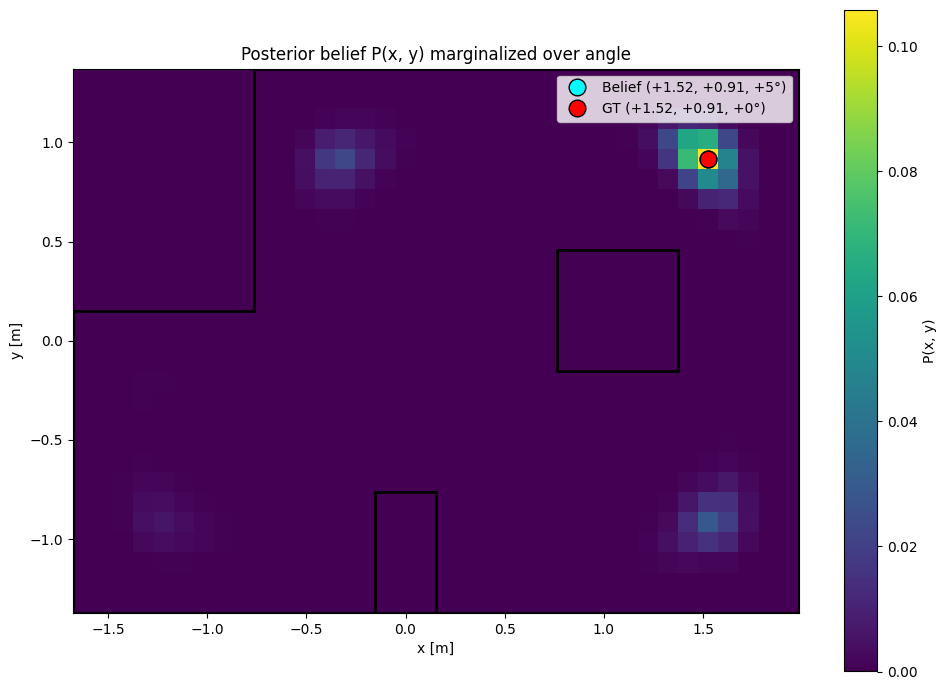

In [18]:
import matplotlib.pyplot as plt
import numpy as np

bel_xy = loc.bel.sum(axis=2)
m = loc.mapper
extent = [m.MIN_X, m.MAX_X, m.MIN_Y, m.MAX_Y]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(
    bel_xy.T,
    origin="lower",
    extent=extent,
    cmap="viridis",
    interpolation="nearest",
)
fig.colorbar(im, ax=ax, label="P(x, y)")

for p, q in robot.config_params["map_lines"]:
    ax.plot([p[0], q[0]], [p[1], q[1]], "k-", lw=2)

bel_cell = np.unravel_index(np.argmax(loc.bel), loc.bel.shape)
bx, by, ba = m.from_map(*bel_cell)
ax.plot(
    bx,
    by,
    "o",
    color="cyan",
    markersize=12,
    markeredgecolor="black",
    label=f"Belief ({bx:+.2f}, {by:+.2f}, {ba:+.0f}\u00b0)",
)

(gx, gy, ga) = GROUND_TRUTH
ax.plot(
    gx,
    gy,
    "o",
    color="red",
    markersize=12,
    markeredgecolor="black",
    label=f"GT ({gx:+.2f}, {gy:+.2f}, {ga:+.0f}\u00b0)",
)

ax.set_xlim(m.MIN_X, m.MAX_X)
ax.set_ylim(m.MIN_Y, m.MAX_Y)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Posterior belief P(x, y) marginalized over angle")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [19]:
gt_world = GROUND_TRUTH  # whatever you placed the robot at
gt_cell = loc.mapper.to_map(*gt_world)
bel_cell = get_max(loc.bel)[0]


z = np.asarray(loc.obs_range_data).flatten()
v_gt = loc.mapper.obs_views[gt_cell]
v_bel = loc.mapper.obs_views[bel_cell]

resid_gt = v_gt - z
resid_bel = v_bel - z
sigma = loc.sensor_sigma

print(
    f"{'i':>2} {'bearing':>7} {'z':>6} {'gt':>6} {'bel':>6} "
    f"{'r_gt':>7} {'r_bel':>7} {'logL_gt':>8} {'logL_bel':>8}"
)
for i in range(loc.mapper.OBS_PER_CELL):
    bearing = i * loc.mapper.RAY_TRACING_ANGLE_INCREMENT
    lg = -0.5 * (resid_gt[i] / sigma) ** 2
    lb = -0.5 * (resid_bel[i] / sigma) ** 2
    print(
        f"{i:2d} {bearing:7.1f} {z[i]:6.2f} {v_gt[i]:6.2f} {v_bel[i]:6.2f} "
        f"{resid_gt[i]:+7.2f} {resid_bel[i]:+7.2f} {lg:8.2f} {lb:8.2f}"
    )

print(f"\nsum logL  GT: {(-0.5 * (resid_gt / sigma) ** 2).sum():.2f}")
print(f"sum logL bel: {(-0.5 * (resid_bel / sigma) ** 2).sum():.2f}")


 i bearing      z     gt    bel    r_gt   r_bel  logL_gt logL_bel
 0     0.0   0.47   0.26   0.46   -0.22   -0.01    -0.37    -0.00
 1    20.0   0.52   0.28   0.51   -0.23   -0.00    -0.43    -0.00
 2    40.0   0.59   0.37   0.59   -0.22   -0.00    -0.39    -0.00
 3    60.0   0.52   0.54   0.51   +0.02   -0.01    -0.00    -0.00
 4    80.0   0.45   0.57   0.46   +0.12   +0.02    -0.11    -0.00
 5   100.0   0.45   0.59   0.48   +0.14   +0.03    -0.15    -0.01
 6   120.0   0.52   0.70   0.57   +0.18   +0.05    -0.26    -0.02
 7   140.0   0.69   1.03   0.84   +0.34   +0.15    -0.93    -0.19
 8   160.0   1.40   2.03   1.75   +0.62   +0.35    -3.12    -0.96
 9   180.0   2.23   2.58   2.37   +0.35   +0.14    -0.97    -0.15
10   200.0   1.79   1.46   2.59   -0.32   +0.80    -0.84    -5.17
11   220.0   0.66   0.58   0.79   -0.08   +0.13    -0.05    -0.13
12   240.0   0.55   1.20   0.57   +0.65   +0.03    -3.42    -0.01
13   260.0   1.03   2.13   1.74   +1.10   +0.71    -9.60    -4.05
14   280.0